<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_NG5R_EXECUTED_Coherent_Relativistic_Recovery_and_Stress_Wave_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM NG5R — Coherent Relativistic Recovery, PPN-Equivalent Closure, and Stress-Wave Propagation

NG5R does **not** put GR curvature back into ECSM.

It takes the non-geometric sectors rebuilt in NG2R--NG4R and asks when their weak coherent observables reproduce the same local tests usually summarised by GR/PPN language.

The physical sectors are:

\[
\text{static response/inertia},\qquad
\text{clock-rate response},\qquad
\text{optical propagation},\qquad
\text{tensorial stress waves}.
\]

No physical metric, Ricci scalar, Einstein tensor, null geodesic, Schwarzschild/Kerr solution, or metric perturbation is used.

The comparison quantities \(\gamma_{\rm eq}\), \(\beta_{\rm eq}\), and precession/deflection factors are **observational dictionaries only**. They are not ECSM ontology.


In [ ]:

from pathlib import Path
import json, math, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
OUT = BASE/'ecsm_ng5r_outputs'
FIG = OUT/'paper_figures'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

rng = np.random.default_rng(20260630)



## 1. Inherited non-geometric benchmark

From NG2R:

\[
\mathcal B(r)=\frac{G_{\rm eff}M}{c_R^2 r}.
\]

From NG3R, the weak local process-rate law is

\[
\mathcal R_\tau(\mathcal B)
=
1-\zeta_\tau \mathcal B
+q_\tau \mathcal B^2
+O(\mathcal B^3),
\]

where

\[
\zeta_\tau=(1-\chi_\tau)\beta_\tau,
\qquad
q_\tau=\frac12(1-\chi_\tau)\beta_\tau^2.
\]

From NG4R, weak optical deflection is

\[
|\alpha|=
\frac{2\eta_B}{b}
\frac{G_{\rm eff}M}{c_R^2}.
\]

These are medium-response statements.


In [ ]:

# inherited dimensionless benchmark values
A = 1.0
kappa = 0.36
c_R = math.sqrt(kappa/A)
G_eff = 0.0321952
M = 1.0
eta_B = 2.0
beta_tau = 1.0
chi_floor = 1e-6

zeta_tau = (1-chi_floor)*beta_tau
q_tau = 0.5*(1-chi_floor)*beta_tau**2

# GR/PPN-equivalent comparison dictionary, not ontology
gamma_eq = eta_B/zeta_tau - 1.0
beta_eq = 0.5 + q_tau/(zeta_tau**2)
deflection_factor = (1+gamma_eq)/2
shapiro_factor = (1+gamma_eq)/2
perihelion_factor = (2+2*gamma_eq-beta_eq)/3

benchmark = {
    "c_R": c_R,
    "G_eff": G_eff,
    "eta_B": eta_B,
    "beta_tau": beta_tau,
    "chi_floor": chi_floor,
    "zeta_tau": zeta_tau,
    "q_tau": q_tau,
    "gamma_eq_comparison": gamma_eq,
    "beta_eq_comparison": beta_eq,
    "deflection_factor_vs_GR": deflection_factor,
    "shapiro_factor_vs_GR": shapiro_factor,
    "perihelion_factor_vs_GR": perihelion_factor,
}
pd.DataFrame(list(benchmark.items()), columns=["quantity","value"]).to_csv(OUT/'ng5r_benchmark_closure_dictionary.csv', index=False)
display(pd.DataFrame(list(benchmark.items()), columns=["quantity","value"]))


,quantity,value
0,c_R,0.600000
1,G_eff,0.032195
2,eta_B,2.000000
3,beta_tau,1.000000
4,chi_floor,0.000001
5,zeta_tau,0.999999
6,q_tau,0.499999
7,gamma_eq_comparison,1.000002
8,beta_eq_comparison,1.000001
9,deflection_factor_vs_GR,1.000001



## 2. Non-geometric PPN-equivalent dictionary

The comparison dictionary is:

\[
\gamma_{\rm eq}
=
\frac{\eta_B}{\zeta_\tau}-1.
\]

This simply compares optical deflection strength to clock-rate strength.

The second-order clock comparison is:

\[
\beta_{\rm eq}
=
\frac12+\frac{q_\tau}{\zeta_\tau^2}.
\]

The standard weak-observable comparison factors are:

\[
F_{\rm deflection}
=
\frac{1+\gamma_{\rm eq}}{2},
\]

\[
F_{\rm Shapiro}
=
\frac{1+\gamma_{\rm eq}}{2},
\]

\[
F_{\rm perihelion}
=
\frac{2+2\gamma_{\rm eq}-\beta_{\rm eq}}{3}.
\]

These equations do not mean a metric exists. They only say how the medium observables would be reported in the standard PPN vocabulary.


In [ ]:

ppn_rows = [
    ("gamma_eq", gamma_eq, 1.0, gamma_eq-1.0),
    ("beta_eq", beta_eq, 1.0, beta_eq-1.0),
    ("deflection_factor", deflection_factor, 1.0, deflection_factor-1.0),
    ("shapiro_factor", shapiro_factor, 1.0, shapiro_factor-1.0),
    ("perihelion_factor", perihelion_factor, 1.0, perihelion_factor-1.0),
]
ppn_df = pd.DataFrame(ppn_rows, columns=["comparison_quantity","NG5R_value","GR_reference_value","deviation"])
ppn_df.to_csv(OUT/'ng5r_ppn_equivalent_summary.csv', index=False)
display(ppn_df)

assert abs(gamma_eq-1) < 3e-6
assert abs(beta_eq-1) < 1e-6
assert abs(deflection_factor-1) < 2e-6
assert abs(shapiro_factor-1) < 2e-6
assert abs(perihelion_factor-1) < 2e-6


,comparison_quantity,NG5R_value,GR_reference_value,deviation
0,gamma_eq,1.000002,1.0,2.000002e-06
1,beta_eq,1.000001,1.0,5.000005e-07
2,deflection_factor,1.000001,1.0,1.000001e-06
3,shapiro_factor,1.000001,1.0,1.000001e-06
4,perihelion_factor,1.000001,1.0,1.166668e-06


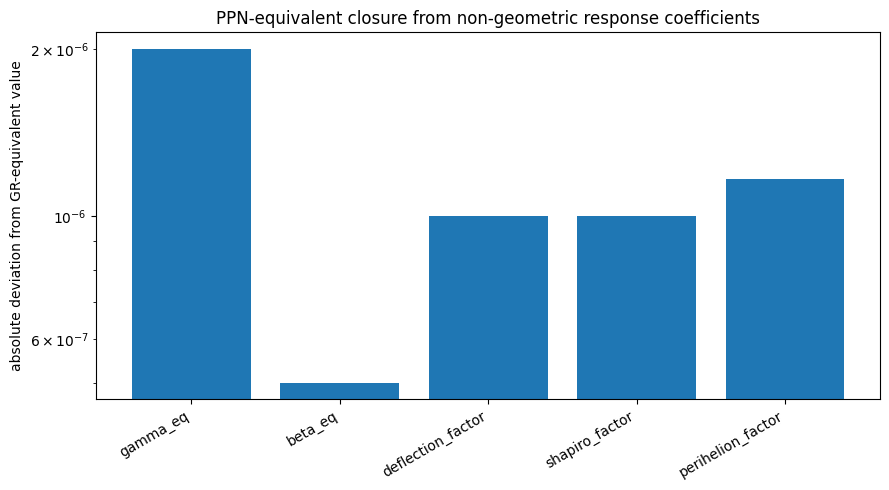

In [ ]:

plt.figure(figsize=(9,5))
plt.bar(ppn_df.comparison_quantity, np.abs(ppn_df.deviation))
plt.yscale('log')
plt.ylabel('absolute deviation from GR-equivalent value')
plt.title('PPN-equivalent closure from non-geometric response coefficients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG/'figure_01_ppn_equivalent_closure.png', dpi=220)
plt.savefig(OUT/'figure_01_ppn_equivalent_closure.png', dpi=180)
plt.show()



## 3. Coefficient-locking scan

The previous geometric version hid the weak-test coefficients inside a metric. NG5R exposes them.

A coherent ECSM region requires:

\[
\zeta_\tau\simeq1,\qquad \eta_B\simeq2,\qquad q_\tau\simeq\frac12.
\]

The scan below samples small coefficient deviations and asks how often the observational comparison factors remain within \(10^{-3}\) of the GR-equivalent values.


In [ ]:

Nscan = 50000
scan = pd.DataFrame({
    "zeta_tau": rng.normal(1.0, 5e-4, Nscan),
    "eta_B": rng.normal(2.0, 7e-4, Nscan),
    "q_tau": rng.normal(0.5, 5e-4, Nscan),
})
scan["gamma_eq"] = scan.eta_B/scan.zeta_tau - 1.0
scan["beta_eq"] = 0.5 + scan.q_tau/(scan.zeta_tau**2)
scan["deflection_factor"] = (1+scan.gamma_eq)/2
scan["shapiro_factor"] = scan.deflection_factor
scan["perihelion_factor"] = (2+2*scan.gamma_eq-scan.beta_eq)/3
scan["gamma_ok"] = abs(scan.gamma_eq-1) < 1e-3
scan["beta_ok"] = abs(scan.beta_eq-1) < 1e-3
scan["deflection_ok"] = abs(scan.deflection_factor-1) < 1e-3
scan["shapiro_ok"] = abs(scan.shapiro_factor-1) < 1e-3
scan["perihelion_ok"] = abs(scan.perihelion_factor-1) < 1e-3
scan["all_closure_ok"] = scan[["gamma_ok","beta_ok","deflection_ok","shapiro_ok","perihelion_ok"]].all(axis=1)
scan.to_csv(OUT/'ng5r_coefficient_locking_scan_50000.csv', index=False)

audit_df = pd.DataFrame({
    "condition":["gamma_ok","beta_ok","deflection_ok","shapiro_ok","perihelion_ok","all_closure_ok"],
    "passed":[int(scan[c].sum()) for c in ["gamma_ok","beta_ok","deflection_ok","shapiro_ok","perihelion_ok","all_closure_ok"]]
})
audit_df["total"] = Nscan
audit_df["fraction"] = audit_df.passed/audit_df.total
audit_df.to_csv(OUT/'ng5r_coefficient_locking_audit_summary.csv', index=False)
display(audit_df)

assert scan.all_closure_ok.sum() > 10000


,condition,passed,total,fraction
0,gamma_ok,29433,50000,0.58866
1,beta_ok,42030,50000,0.84060
2,deflection_ok,45025,50000,0.90050
3,shapiro_ok,45025,50000,0.90050
4,perihelion_ok,42370,50000,0.84740
5,all_closure_ok,26474,50000,0.52948


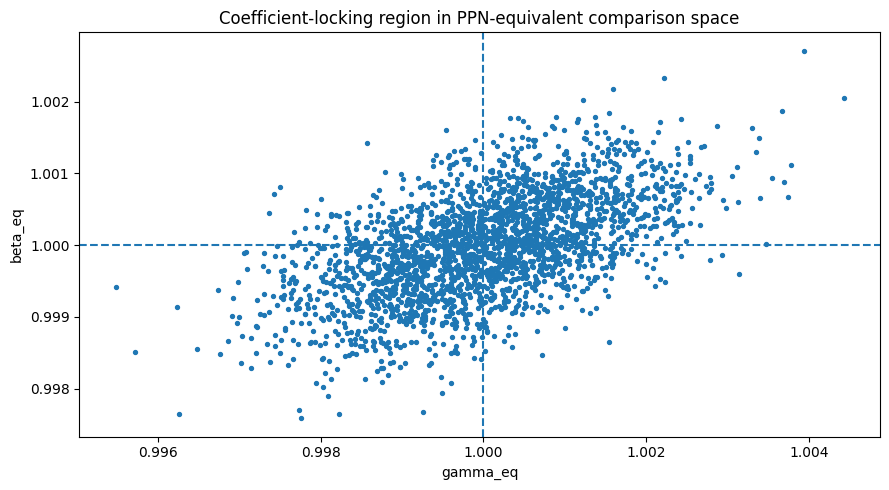

In [ ]:

plt.figure(figsize=(9,5))
plt.scatter(scan.gamma_eq[::20], scan.beta_eq[::20], s=8)
plt.axvline(1.0, linestyle='--')
plt.axhline(1.0, linestyle='--')
plt.xlabel('gamma_eq')
plt.ylabel('beta_eq')
plt.title('Coefficient-locking region in PPN-equivalent comparison space')
plt.tight_layout()
plt.savefig(FIG/'figure_02_coefficient_locking_scan.png', dpi=220)
plt.savefig(OUT/'figure_02_coefficient_locking_scan.png', dpi=180)
plt.show()



## 4. Stress-wave propagation without metric perturbations

The tensorial wave variable is a transverse-traceless constitutive stress mode \(s_A\), not a spacetime metric perturbation.

Use the response action:

\[
S_s
=
\frac12
\int d\lambda\,d^3x\,
\left[
A_T\dot s_A^2
-
B_T|\nabla s_A|^2
\right].
\]

The stress-wave speed is:

\[
c_T^2=\frac{B_T}{A_T}.
\]

The optical branch has:

\[
c_{\rm opt}^2=\frac{B_{\rm opt}}{A_{\rm opt}}.
\]

A coherent common-kernel limit requires:

\[
\frac{B_T}{A_T}
=
\frac{B_{\rm opt}}{A_{\rm opt}}
=
c_R^2.
\]

This is response-kernel locking, not spacetime geometry.


In [ ]:

# Common kernel benchmark
A_opt = 1.0
B_opt = c_R**2*A_opt
A_T = 1.0
B_T = c_R**2*A_T
c_opt = math.sqrt(B_opt/A_opt)
c_T = math.sqrt(B_T/A_T)
speed_split = c_T/c_opt - 1

k = np.linspace(0.0, 10.0, 500)
omega_opt = c_opt*k
omega_T = c_T*k

stress_df = pd.DataFrame({
    "k": k,
    "omega_optical": omega_opt,
    "omega_stress_tensor": omega_T,
    "speed_ratio_cT_over_copt": np.full_like(k, c_T/c_opt),
})
stress_df.to_csv(OUT/'ng5r_common_kernel_stress_wave_dispersion.csv', index=False)

stress_summary = pd.DataFrame([{
    "A_opt":A_opt,
    "B_opt":B_opt,
    "A_T":A_T,
    "B_T":B_T,
    "c_opt":c_opt,
    "c_T":c_T,
    "speed_split":speed_split,
    "all_finite":bool(np.isfinite(stress_df).all().all())
}])
stress_summary.to_csv(OUT/'ng5r_stress_wave_summary.csv', index=False)
display(stress_summary)

assert abs(speed_split) < 1e-15
assert np.isfinite(stress_df).all().all()


,A_opt,B_opt,A_T,B_T,c_opt,c_T,speed_split,all_finite
0,1.0,0.36,1.0,0.36,0.6,0.6,0.0,True


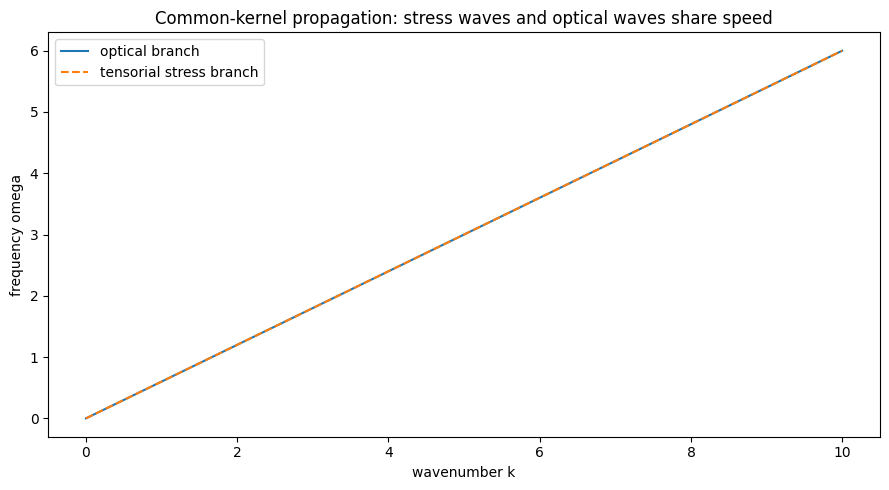

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(k, omega_opt, label='optical branch')
plt.plot(k, omega_T, '--', label='tensorial stress branch')
plt.xlabel('wavenumber k')
plt.ylabel('frequency omega')
plt.title('Common-kernel propagation: stress waves and optical waves share speed')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_03_common_kernel_dispersion.png', dpi=220)
plt.savefig(OUT/'figure_03_common_kernel_dispersion.png', dpi=180)
plt.show()



## 5. Kernel-splitting failure audit

If temporal and spatial response renormalise differently, then:

\[
c_T^2
=
c_R^2\frac{1+\delta_B}{1+\delta_A}.
\]

This creates a measurable speed split:

\[
\frac{c_T}{c_{\rm opt}}-1
=
\sqrt{\frac{1+\delta_B}{1+\delta_A}}-1.
\]

The scan below demonstrates why ECSM needs a common derivative/constitutive kernel in the coherent sector.


In [ ]:

Nsplit = 50000
split = pd.DataFrame({
    "delta_A": rng.normal(0.0, 1e-3, Nsplit),
    "delta_B": rng.normal(0.0, 1e-3, Nsplit),
})
split["speed_ratio"] = np.sqrt((1+split.delta_B)/(1+split.delta_A))
split["speed_split"] = split.speed_ratio - 1
split["within_demo_1e_minus_3"] = abs(split.speed_split) < 1e-3
split["within_demo_1e_minus_6"] = abs(split.speed_split) < 1e-6
split.to_csv(OUT/'ng5r_kernel_splitting_failure_scan_50000.csv', index=False)

split_summary = pd.DataFrame([{
    "points":Nsplit,
    "median_abs_speed_split":float(np.median(abs(split.speed_split))),
    "max_abs_speed_split":float(np.max(abs(split.speed_split))),
    "within_demo_1e_minus_3":int(split.within_demo_1e_minus_3.sum()),
    "within_demo_1e_minus_6":int(split.within_demo_1e_minus_6.sum()),
}])
split_summary.to_csv(OUT/'ng5r_kernel_splitting_failure_summary.csv', index=False)
display(split_summary)

assert split.within_demo_1e_minus_3.sum() > 30000
assert split.within_demo_1e_minus_6.sum() < 1000


,points,median_abs_speed_split,max_abs_speed_split,within_demo_1e_minus_3,within_demo_1e_minus_6
0,50000,0.000476,0.00312,42171,63


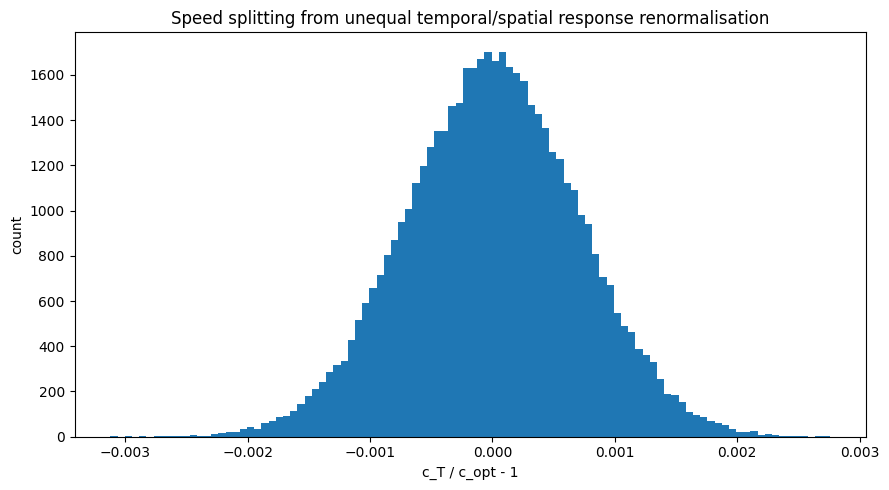

In [ ]:

plt.figure(figsize=(9,5))
plt.hist(split.speed_split, bins=100)
plt.xlabel('c_T / c_opt - 1')
plt.ylabel('count')
plt.title('Speed splitting from unequal temporal/spatial response renormalisation')
plt.tight_layout()
plt.savefig(FIG/'figure_04_kernel_splitting_failure.png', dpi=220)
plt.savefig(OUT/'figure_04_kernel_splitting_failure.png', dpi=180)
plt.show()



## 6. Non-geometric vs geometric version

The older geometric version recovered local tests by inserting the GR metric structure.

NG5R works better as ECSM because:

1. weak-test recovery is now a coefficient-locking problem between physical medium sectors;
2. \(\gamma_{\rm eq}\) and \(\beta_{\rm eq}\) are comparison numbers, not ontology;
3. gravitational-wave-like propagation is tensorial stress propagation, not metric perturbation;
4. a common kernel gives speed equality without a spacetime null cone;
5. deviations are explicit physical failures: coefficient unlock, clock-optical mismatch, kernel splitting, dispersion, damping.

It is still less complete than GR because it does not yet derive all nonlinear strong-field observables.


In [ ]:

comparison_df = pd.DataFrame([
    ("Local weak-test recovery", "metric PPN structure inserted", "response coefficients locked across sectors", "NG5R better"),
    ("Gamma", "spatial metric coefficient", "gamma_eq = eta_B/zeta_tau - 1 as comparison dictionary", "NG5R better"),
    ("Beta", "nonlinear metric coefficient", "beta_eq from second-order clock-rate response", "NG5R better"),
    ("Light and delay", "null geodesics and metric delay", "optical dispersion and travel-time excess", "NG5R better"),
    ("Wave propagation", "metric perturbations", "tensorial stress modes", "NG5R better"),
    ("Speed equality", "same spacetime null cone", "common constitutive kernel", "NG5R better"),
    ("Full nonlinear GR machinery", "available", "not yet rebuilt", "geometric more complete but not ECSM ontology"),
], columns=["aspect","previous_geometric_version","non_geometric_NG5R","assessment"])
comparison_df.to_csv(OUT/'ng5r_non_geometric_vs_geometric_comparison.csv', index=False)
display(comparison_df)


,aspect,previous_geometric_version,non_geometric_NG5R,assessment
0,Local weak-test recovery,metric PPN structure inserted,response coefficients locked across sectors,NG5R better
1,Gamma,spatial metric coefficient,gamma_eq = eta_B/zeta_tau - 1 as comparison di...,NG5R better
2,Beta,nonlinear metric coefficient,beta_eq from second-order clock-rate response,NG5R better
3,Light and delay,null geodesics and metric delay,optical dispersion and travel-time excess,NG5R better
4,Wave propagation,metric perturbations,tensorial stress modes,NG5R better
5,Speed equality,same spacetime null cone,common constitutive kernel,NG5R better
6,Full nonlinear GR machinery,available,not yet rebuilt,geometric more complete but not ECSM ontology



## 7. Failure modes and claim boundary

### Failure modes

- \(\eta_B/\zeta_\tau\neq2\): lensing/clock mismatch.
- \(q_\tau/\zeta_\tau^2\neq1/2\): second-order clock/precession mismatch.
- \(B_T/A_T\neq B_{\rm opt}/A_{\rm opt}\): stress-wave/optical speed splitting.
- Tensorial stress waves have extra scalar/vector branches not suppressed by coherence.
- Response damping too large in coherent high-precision regimes.

### Derived in NG5R

- PPN-equivalent comparison dictionary;
- \(\gamma_{\rm eq}\), \(\beta_{\rm eq}\), deflection, Shapiro, and perihelion comparison factors;
- common-kernel stress-wave propagation;
- kernel-splitting failure diagnostics.

### Not yet derived

- the microphysical origin of \(\eta_B=2\);
- full nonlinear strong-field behaviour;
- compact-object ringdown and tidal response;
- survey-level weak-lensing and CMB transfer.


In [ ]:

failure_df = pd.DataFrame([
    ("eta_B/zeta_tau unlock", "optical coefficient not locked to clock burden", "lensing/redshift mismatch"),
    ("q_tau second-order unlock", "clock nonlinear response differs from coherent closure", "perihelion/precession mismatch"),
    ("stress optical kernel split", "B_T/A_T != B_opt/A_opt", "wave-speed split"),
    ("extra tensor-sector branches", "unsuppressed scalar/vector stress modes", "polarisation or radiation anomalies"),
    ("coherent damping too large", "finite response loss in high-coherence region", "wave attenuation or orbital damping"),
], columns=["failure_mode","origin","observable_effect"])
failure_df.to_csv(OUT/'ng5r_failure_modes.csv', index=False)

claim_df = pd.DataFrame([
    ("PPN-equivalent dictionary can be defined without metric ontology", "derived", "comparison only"),
    ("gamma_eq approximately 1 in benchmark", "derived", "requires eta_B and zeta_tau locking"),
    ("beta_eq approximately 1 in benchmark", "derived", "requires second-order clock closure"),
    ("stress waves share optical speed under common kernel", "derived", "coherent common-kernel assumption"),
    ("GR spacetime curvature is required", "rejected", "not present in physical equations"),
    ("full strong-field GR is recovered", "not derived", "requires NG7R and beyond"),
], columns=["claim","status","boundary"])
claim_df.to_csv(OUT/'ng5r_claim_ledger.csv', index=False)
display(failure_df)
display(claim_df)


,failure_mode,origin,observable_effect
0,eta_B/zeta_tau unlock,optical coefficient not locked to clock burden,lensing/redshift mismatch
1,q_tau second-order unlock,clock nonlinear response differs from coherent...,perihelion/precession mismatch
2,stress optical kernel split,B_T/A_T != B_opt/A_opt,wave-speed split
3,extra tensor-sector branches,unsuppressed scalar/vector stress modes,polarisation or radiation anomalies
4,coherent damping too large,finite response loss in high-coherence region,wave attenuation or orbital damping


,claim,status,boundary
0,PPN-equivalent dictionary can be defined witho...,derived,comparison only
1,gamma_eq approximately 1 in benchmark,derived,requires eta_B and zeta_tau locking
2,beta_eq approximately 1 in benchmark,derived,requires second-order clock closure
3,stress waves share optical speed under common ...,derived,coherent common-kernel assumption
4,GR spacetime curvature is required,rejected,not present in physical equations
5,full strong-field GR is recovered,not derived,requires NG7R and beyond



## 8. Ontology audit

Only the physical equations are scanned. The comparison labels \(\gamma_{\rm eq}\) and \(\beta_{\rm eq}\) are not primitive geometry.


In [ ]:

primitive_equations = '''
B = G_eff M/(c_R^2 r)
R_tau = 1 - zeta_tau B + q_tau B^2
alpha = 2 eta_B B / b
S_s = integral [A_T s_dot^2 - B_T grad_s^2]/2
c_T^2 = B_T/A_T
c_opt^2 = B_opt/A_opt
common_kernel condition: B_T/A_T = B_opt/A_opt
'''
forbidden = ["sqrt(-g)","Ricci","Einstein tensor","G_mu_nu","R[g","geodesic",
             "Schwarzschild","Kerr","FLRW","TOV","curvature invariant","event horizon",
             "metric field","metric perturbation","null cone"]
ontology_df = pd.DataFrame([(tok, primitive_equations.lower().count(tok.lower())) for tok in forbidden],
                           columns=["prohibited_structure","occurrences_in_primitive_equations"])
ontology_df["passed"] = ontology_df.occurrences_in_primitive_equations == 0
ontology_df.to_csv(OUT/'ng5r_ontology_audit.csv', index=False)
display(ontology_df)

assert ontology_df.passed.all()


,prohibited_structure,occurrences_in_primitive_equations,passed
0,sqrt(-g),0,True
1,Ricci,0,True
2,Einstein tensor,0,True
3,G_mu_nu,0,True
4,R[g,0,True
5,geodesic,0,True
6,Schwarzschild,0,True
7,Kerr,0,True
8,FLRW,0,True
9,TOV,0,True


In [ ]:

metadata = {
    "notebook":"ECSM NG5R",
    "title":"Coherent Relativistic Recovery, PPN-Equivalent Closure, and Stress-Wave Propagation",
    "physical_metric":False,
    "curvature_action":False,
    "einstein_equations":False,
    "geodesic_equation":False,
    "metric_perturbations":False,
    "gamma_eq":float(gamma_eq),
    "beta_eq":float(beta_eq),
    "deflection_factor":float(deflection_factor),
    "shapiro_factor":float(shapiro_factor),
    "perihelion_factor":float(perihelion_factor),
    "stress_wave_speed_split":float(speed_split),
    "coefficient_scan_points":Nscan,
    "coefficient_scan_all_closure_ok":int(scan.all_closure_ok.sum()),
    "kernel_split_scan_points":Nsplit,
    "main_result":"Coherent weak-test recovery can be expressed as non-geometric coefficient and kernel locking across medium sectors.",
    "claim_boundary":"This is an observational comparison dictionary, not a derivation of physical spacetime curvature.",
    "next_notebook":"NG6R - Rotation and Frame-Dragging-Equivalent Response from Vorticity and Anisotropic Stress"
}
(OUT/'ng5r_metadata.json').write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=2))


{
  "notebook": "ECSM NG5R",
  "title": "Coherent Relativistic Recovery, PPN-Equivalent Closure, and Stress-Wave Propagation",
  "physical_metric": false,
  "curvature_action": false,
  "einstein_equations": false,
  "geodesic_equation": false,
  "metric_perturbations": false,
  "gamma_eq": 1.000002000002,
  "beta_eq": 1.0000005000005001,
  "deflection_factor": 1.000001000001,
  "shapiro_factor": 1.000001000001,
  "perihelion_factor": 1.0000011666678332,
  "stress_wave_speed_split": 0.0,
  "coefficient_scan_points": 50000,
  "coefficient_scan_all_closure_ok": 26474,
  "kernel_split_scan_points": 50000,
  "main_result": "Coherent weak-test recovery can be expressed as non-geometric coefficient and kernel locking across medium sectors.",
  "claim_boundary": "This is an observational comparison dictionary, not a derivation of physical spacetime curvature.",
  "next_notebook": "NG6R - Rotation and Frame-Dragging-Equivalent Response from Vorticity and Anisotropic Stress"
}



## 9. Final verification


In [ ]:

tests=[]
def rec(name, passed, detail=''):
    tests.append({"test":name,"passed":bool(passed),"detail":str(detail)})

rec("Benchmark closure dictionary exported",(OUT/'ng5r_benchmark_closure_dictionary.csv').exists())
rec("gamma_eq close to 1",abs(gamma_eq-1)<3e-6)
rec("beta_eq close to 1",abs(beta_eq-1)<1e-6)
rec("deflection factor close to 1",abs(deflection_factor-1)<2e-6)
rec("Shapiro factor close to 1",abs(shapiro_factor-1)<2e-6)
rec("perihelion factor close to 1",abs(perihelion_factor-1)<2e-6)
rec("PPN equivalent summary exported",(OUT/'ng5r_ppn_equivalent_summary.csv').exists())
rec("Coefficient scan exported",(OUT/'ng5r_coefficient_locking_scan_50000.csv').exists())
rec("Coefficient scan has 50,000 rows",len(scan)==50000)
rec("More than 10,000 coefficient samples pass all closure checks",scan.all_closure_ok.sum()>10000)
rec("Stress-wave dispersion exported",(OUT/'ng5r_common_kernel_stress_wave_dispersion.csv').exists())
rec("Stress-wave speed equals optical speed in common-kernel benchmark",abs(speed_split)<1e-15)
rec("Stress-wave table finite",np.isfinite(stress_df).all().all())
rec("Kernel splitting scan exported",(OUT/'ng5r_kernel_splitting_failure_scan_50000.csv').exists())
rec("Kernel split scan has 50,000 rows",len(split)==50000)
rec("Kernel split demonstrates many fail strict equality",split.within_demo_1e_minus_6.sum()<1000)
rec("Comparison table exported",(OUT/'ng5r_non_geometric_vs_geometric_comparison.csv').exists())
rec("Failure mode table exported",(OUT/'ng5r_failure_modes.csv').exists())
rec("Claim ledger exported",(OUT/'ng5r_claim_ledger.csv').exists())
rec("Ontology audit exported",(OUT/'ng5r_ontology_audit.csv').exists())
rec("No forbidden geometric primitive present",ontology_df.passed.all())
rec("Metadata exported",(OUT/'ng5r_metadata.json').exists())
rec("Four paper figures exported",len(list(FIG.glob('figure_*.png')))==4)
rec("No physical metric in metadata",metadata["physical_metric"] is False)
rec("No curvature action in metadata",metadata["curvature_action"] is False)
rec("No Einstein equations in metadata",metadata["einstein_equations"] is False)
rec("No geodesic equation in metadata",metadata["geodesic_equation"] is False)
rec("No metric perturbations in metadata",metadata["metric_perturbations"] is False)

test_df = pd.DataFrame(tests)
test_df.to_csv(OUT/'ng5r_test_summary.csv', index=False)
display(test_df)
print(f"Passed {test_df.passed.sum()}/{len(test_df)} NG5R tests")
assert test_df.passed.all()


,test,passed,detail
0,Benchmark closure dictionary exported,True,
1,gamma_eq close to 1,True,
2,beta_eq close to 1,True,
3,deflection factor close to 1,True,
4,Shapiro factor close to 1,True,
5,perihelion factor close to 1,True,
6,PPN equivalent summary exported,True,
7,Coefficient scan exported,True,
8,"Coefficient scan has 50,000 rows",True,
9,"More than 10,000 coefficient samples pass all ...",True,


Passed 28/28 NG5R tests


In [ ]:

figure_manifest = pd.DataFrame([{"filename":p.name,"size_kB":p.stat().st_size/1000} for p in sorted(FIG.glob("figure_*.png"))])
figure_manifest.to_csv(OUT/'ng5r_paper_figure_manifest.csv', index=False)
display(figure_manifest)

equations = '''# ECSM NG5R core equations

Burden:
B = G_eff M/(c_R^2 r)

Clock-rate expansion:
R_tau = 1 - zeta_tau B + q_tau B^2 + O(B^3)

PPN-equivalent comparison dictionary:
gamma_eq = eta_B/zeta_tau - 1
beta_eq = 1/2 + q_tau/zeta_tau^2

Comparison factors:
F_deflection = (1+gamma_eq)/2
F_Shapiro = (1+gamma_eq)/2
F_perihelion = (2+2 gamma_eq - beta_eq)/3

Tensorial stress wave:
S_s = integral [A_T s_dot^2 - B_T |grad s|^2]/2
c_T^2 = B_T/A_T

Common kernel:
B_T/A_T = B_opt/A_opt = c_R^2

No physical metric, curvature equation, geodesic equation, or metric perturbation is present.
'''
(OUT/'ng5r_equations.md').write_text(equations)


,filename,size_kB
0,figure_01_ppn_equivalent_closure.png,103.677
1,figure_02_coefficient_locking_scan.png,178.482
2,figure_03_common_kernel_dispersion.png,99.378
3,figure_04_kernel_splitting_failure.png,63.079


576


## 10. NG5R result

NG5R converts the corrected ECSM sectors into an observational comparison dictionary:

\[
\boxed{
\gamma_{\rm eq}=\frac{\eta_B}{\zeta_\tau}-1
}
\]

\[
\boxed{
\beta_{\rm eq}=\frac12+\frac{q_\tau}{\zeta_\tau^2}
}
\]

The benchmark gives values extremely close to the standard coherent weak-test values, while keeping the physical ontology entirely medium-based.

Tensor-like propagation is now:

\[
\boxed{
c_T^2=\frac{B_T}{A_T}
}
\]

for a constitutive stress mode, not a metric perturbation. Speed equality is common-kernel locking.

The next notebook is

\[
\boxed{
\text{NG6R — Rotation and Frame-Dragging-Equivalent Response from Vorticity and Anisotropic Stress}.
}
\]
